Importing Packages
---

In [26]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import scipy.optimize as op
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata

Loading Dataset
---

In [27]:
#Separating dataset
#Note, the seed based on which the splitting is done is hardcoded into the function
def separate_files(file_pattern):
    #Reading labels from the file names
    all_files = sorted(glob.glob(file_pattern))

    phases_all = []
    for file_path in all_files:
        basename = os.path.basename(file_path)
        name_without_ext = os.path.splitext(basename)[0]
        tokens = name_without_ext.split('_')
        phases_all.append(1 if tokens[2] == 'above' else 0)
     
    list_train, list_remainder = train_test_split(
    all_files, test_size=0.4, stratify=phases_all, random_state=1
    )

    phases_remainder = []
    for file_path in list_remainder:
            basename = os.path.basename(file_path)
            name_without_ext = os.path.splitext(basename)[0]
            tokens = name_without_ext.split('_')
            phases_remainder.append(1 if tokens[2] == 'above' else 0)

    list_eval, list_test = train_test_split(
    list_remainder, test_size=0.5, stratify=phases_remainder, random_state=2
    )
    return list_train, list_eval, list_test

#A portion of the data is stored in the file name, we read these separately from the actual
#matrices, so that they may be cycled in and out of memory as necessary.
def read_file_parameters(file_path):
    basename = os.path.basename(file_path)
    name_without_ext = os.path.splitext(basename)[0]
    tokens = name_without_ext.split('_')

    beta  = float(tokens[0])
    h = float(tokens[1])
    phase = 1 if tokens[2] == 'above' else 0
    
    return beta, h, phase

def load_directory(file_pattern):
    list_train, list_eval, list_test = separate_files(file_pattern)

    parameters_train = [read_file_parameters(file_path) for file_path in list_train]
    parameters_eval = [read_file_parameters(file_path) for file_path in list_eval]
    parameters_test = [read_file_parameters(file_path) for file_path in list_test]

    betas_train, hs_train, phases_train = np.array(parameters_train).T
    betas_eval, hs_eval, phases_eval = np.array(parameters_eval).T
    betas_test, hs_test, phases_test = np.array(parameters_test).T
    #With this we now have an array of each parameter and a list of files separated
    #into train and test sets

    return (list_train, betas_train, hs_train, phases_train,
            list_eval, betas_eval, hs_eval, phases_eval,
            list_test, betas_test, hs_test, phases_test)

#Loading dataset
(list_train, betas_train, hs_train, phases_train,
 list_eval, betas_eval, hs_eval, phases_eval,
 list_test, betas_test, hs_test, phases_test) = load_directory("../2dIsingData/zero_h/*.npz")

#A bit roundabout, but will be necessary in order for homogeneous sampling of labels across datasets

The Data
---
We have two datasets, one with varying temperatures and no external field, and another with varying external positive field.

The following is a visualization of the system we will be investigating

(Note that the first and last rows and columns are fixed:)
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.] 



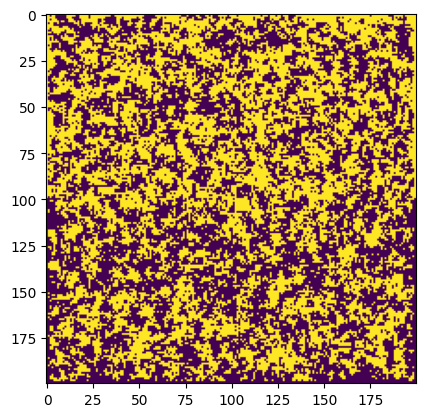

In [28]:
def matrix_from_file(file_path):
    with np.load(file_path) as data:
        matrix = data['sigma'].copy()
    return matrix
    
np.random.seed(3)
sample_number = np.random.randint(0, len(list_train))
example_grid = matrix_from_file(list_train[sample_number])

print("The following is a visualization of the system we will be investigating\n")
plt.imshow(example_grid)

print("(Note that the first and last rows and columns are fixed:)\n", example_grid[0], "\n")

Fully Connected Network for the h = 0 Dataset
---

In [29]:
#Build the model
N = 200
FCNN_zero_h = models.Sequential([
    layers.Input(shape=(N**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_zero_h.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
#Visualizes hyperparameter space
def plot_BS_Ec(Ecs, BSs, errors, title, cmap='viridis', highlight_color='red'):
    plt.figure(figsize=(8, 6))
    
    scatter = plt.scatter(Ecs, BSs, c=errors, cmap=cmap, edgecolor='none', alpha=0.8, s=50, label="Total label error")

    cbar = plt.colorbar(scatter)
    cbar.set_label('Total label error', rotation=270, labelpad=15)
    
    min_idx = np.argmin(errors)
    x_min, y_min = Ecs[min_idx], BSs[min_idx]
    
    plt.scatter(x_min, y_min, color='none', edgecolor=highlight_color, 
                s=150, linewidths=2, label="Winning configuration")
    
    plt.xlabel('Number of Epochs')
    plt.ylabel('Batch size exponent')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

#Returns submatrix from training sample
def random_crop(matrix, size):
    
    h, w = matrix.shape
    # Calculate the maximum valid starting indices to prevent out-of-bounds errors
    max_h = h - size
    max_w = w - size
    
    # Pick random starting coordinates
    start_h = np.random.randint(0, max_h + 1)
    start_w = np.random.randint(0, max_w + 1)
    
    return matrix[start_h : start_h + size, start_w : start_w + size]

#Training the model
#This might seem redundant as there are built in one-liners for this in the libraries
#that we are using in this discussion, but this function rotates the training matrices
#in and out of RAM in batches.
#This will be relevant for the other dataset which is quite large.
def train_by_batch_crop(model, list_train, phases_train, flatten, BATCH_SIZE, EPOCHS, CROP):
    num_samples = len(list_train)

    for epoch in range(EPOCHS):
        #print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0
        
        for i in range(0, num_samples, BATCH_SIZE):
            batch_files = list_train[i : i + BATCH_SIZE]
            batch_labels = phases_train[i : i + BATCH_SIZE]
            
            batch_features = []
            for file_path in batch_files:
                with np.load(file_path) as data:
                    batch_features.append(random_crop(data['sigma'].copy(), CROP))

            if(flatten == 1):
                X_batch = np.array(batch_features).reshape(len(batch_files), -1)
            else:
                X_batch = np.array(batch_features)[..., np.newaxis]
            y_batch = np.array(batch_labels)
            
            metrics = model.train_on_batch(X_batch, y_batch)
            
            # Accumulate metrics across all batches
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1

        # Calculate and print the true global metric of the dataset
        #print(f"Average Loss: {epoch_loss / batch_count:.4f} - Average Accuracy: {epoch_acc / batch_count:.4f}")


Visualizing the Critical Temperature Using the Model
---

In [31]:
#This function takes uniformly distributed points from the hyperparameter plane passed and returns the best model found
def hyper_parameter_search(model, list_train, list_eval, list_test, phases_train, phases_eval, CROP, BS_exponent_interval, E_interval, iter, title, flatten):
    eval_matrices = np.array([matrix_from_file(file_path) for file_path in list_eval])
    cropped_eval_matrices = np.array([random_crop(eval_matrix[:], CROP) for eval_matrix in eval_matrices])

    zero_weights = model.get_weights()
    best_weights = model.get_weights()
    errors = []
    BS_exponents = []
    Ecs = []
    winning_index = 0
    for i in range(iter):
        BS_exponents.append(np.random.randint(BS_exponent_interval[0], BS_exponent_interval[1]))
        Ecs.append(np.random.randint(E_interval[0], E_interval[1]))

        model.set_weights(zero_weights)

        train_by_batch_crop(model, list_train, phases_train, flatten=flatten, BATCH_SIZE=2**BS_exponents[i], EPOCHS=Ecs[i], CROP=CROP)
        if flatten == 1:
            predictions = model.predict(cropped_eval_matrices.reshape(len(list_eval), -1))
        else:
            predictions = model.predict(cropped_eval_matrices[..., np.newaxis])
        error_temporary = np.sum(np.abs(predictions.ravel() - phases_eval))

        errors.append(error_temporary)

        if error_temporary < errors[winning_index] or i == 0:
            best_weights = model.get_weights()
            winning_index = i

        #print(f"Iteration {(i+1)}/{iter} done. BS = {2**BS_exponents[i]} and Ec = {Ecs[i]} resulted in error = {errors[i]:.2E}")

    errors = np.array(errors)
    BS_exponents = np.array(BS_exponents)
    Ecs = np.array(Ecs)
    
    model.set_weights(best_weights)
    test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
    cropped_test_matrices = np.array([random_crop(test_matrix[:], CROP) for test_matrix in test_matrices])
    if flatten == 1:
        predictions = model.predict(cropped_test_matrices.reshape(len(list_test), -1))
    else:
        predictions = model.predict(cropped_test_matrices[..., np.newaxis])
    #print(f"Best epoch count found:{Ecs[winning_index]}\n",
    #      f"Best batch size found:{2**BS_exponents[winning_index]}\n",
    #      f"Total label deviation was:{errors[winning_index]:.2E}\n")
    plot_BS_Ec(Ecs, BS_exponents, errors, title)
    return best_weights, predictions

2/2 [==============================] - 0s 3ms/step


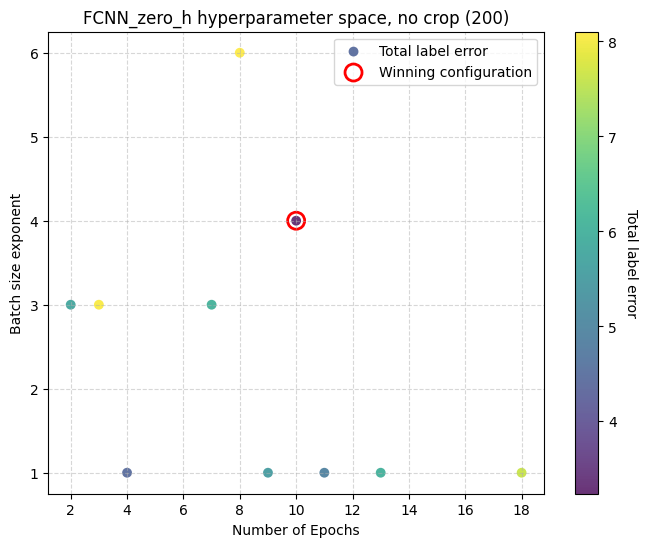

In [32]:
FCNN_zero_h_weights, predictions = hyper_parameter_search(FCNN_zero_h, list_train, list_eval, list_test, phases_train, phases_eval, CROP=200,
                                                         BS_exponent_interval=[1, 7], E_interval=[1, 20], iter=10, 
                                                         title="FCNN_zero_h hyperparameter space, no crop (200)", flatten = 1)
FCNN_zero_h.set_weights(FCNN_zero_h_weights)

In [33]:
literature_beta = 0.4407
#A steep sigmoid for fitting
def smooth_crit_temp(beta, a, k=50):
    return 1 / (1 + np.exp(k * (beta - a)))

#Visualizes model performance
def fit_critical(betas_test, phases_test, predictions, title):
    plt.scatter(betas_test, phases_test, label='Ground truth', marker = '3')
    plt.scatter(betas_test, predictions, label='Model\'s last layer', marker = '4')
    popt, pcov = op.curve_fit(smooth_crit_temp, betas_test, predictions.flatten(), p0=[0.4])
    plt.vlines(popt[0], 0, 1, colors='b', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')
    plt.xlabel("Inverse temperature beta")
    plt.ylabel("Above critical or not")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


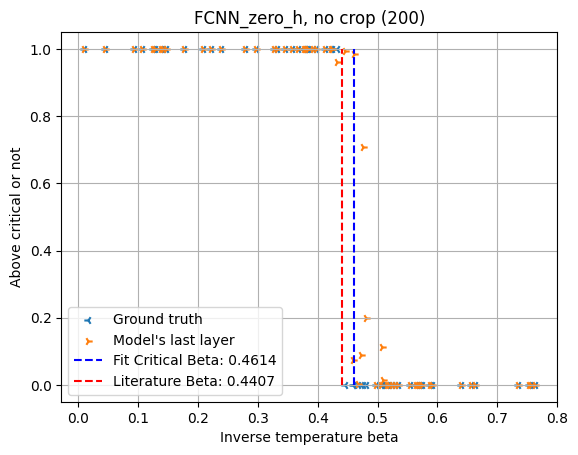

In [34]:
fit_critical(betas_test, phases_test, predictions,"FCNN_zero_h, no crop (200)")

The model performs fairly well, but as we'll see it and others similar to it consistently converge such that they overestimate T_c (Or equivalently -under Beta_c). This is likely due to having broken the positive/negative symmetry of the problem somewhere along the way. For instance with the use of ReLU and later with the magnetic field being strictly positive.

Fitting on Submatrices
---

2/2 [==============================] - 0s 3ms/step


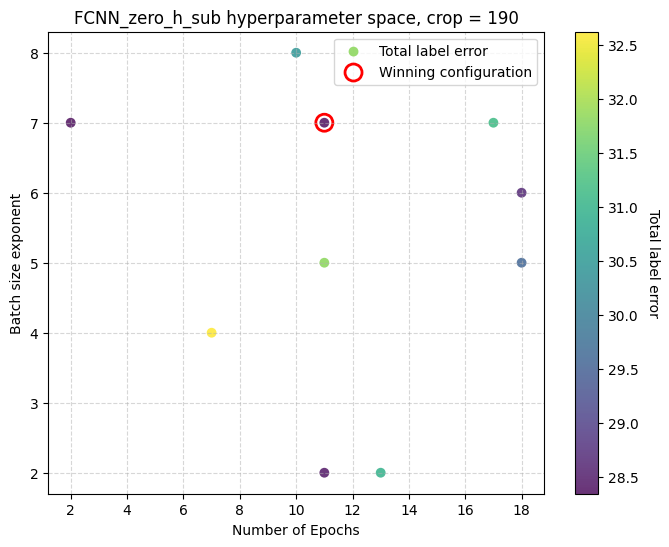

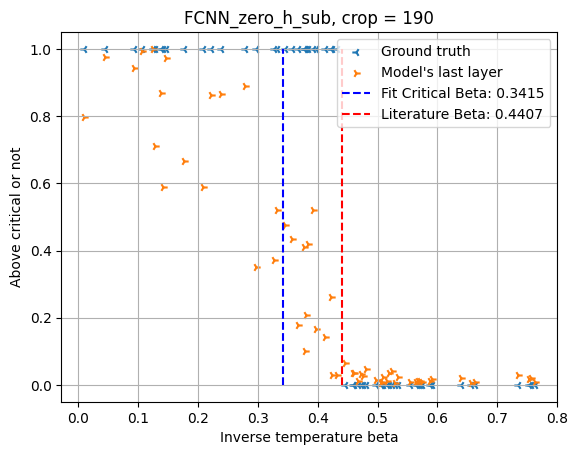

2/2 [==============================] - 0s 4ms/step


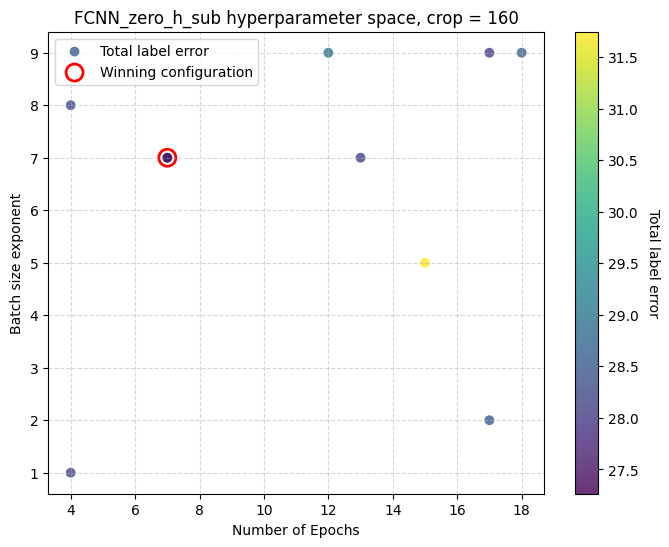

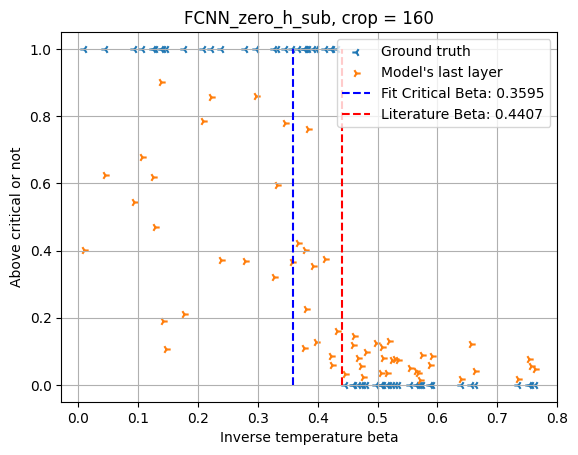

2/2 [==============================] - 0s 0s/step


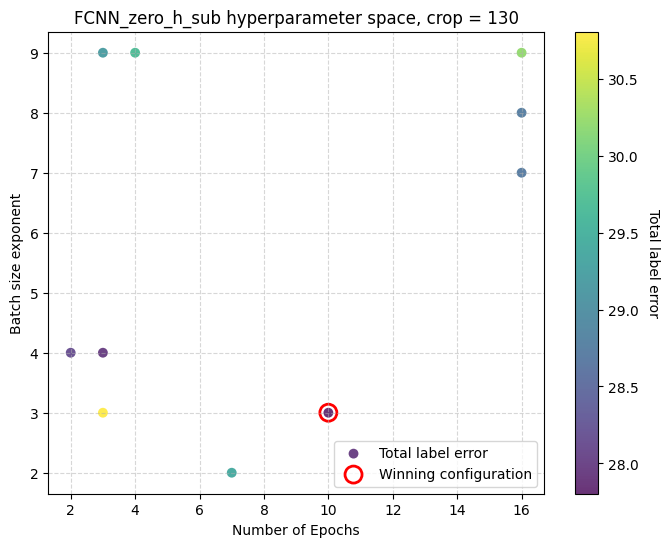

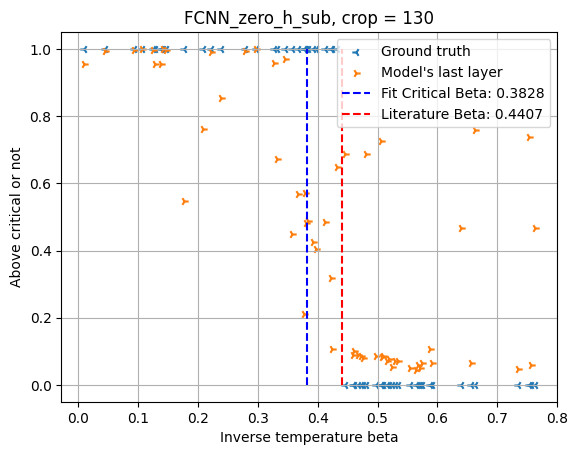

2/2 [==============================] - 0s 0s/step


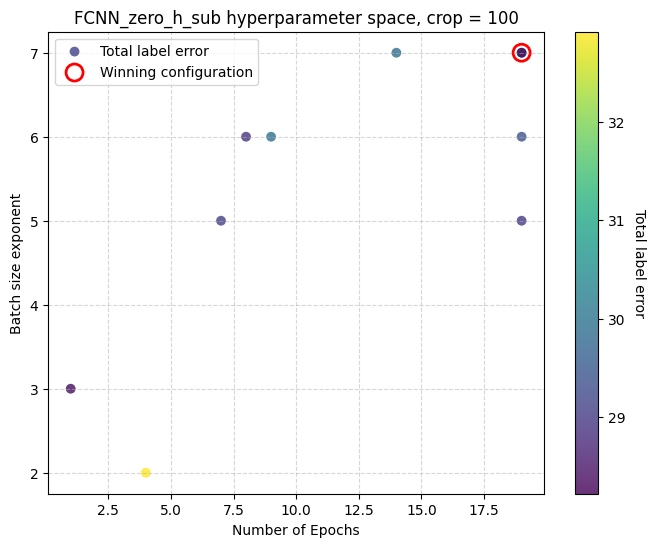

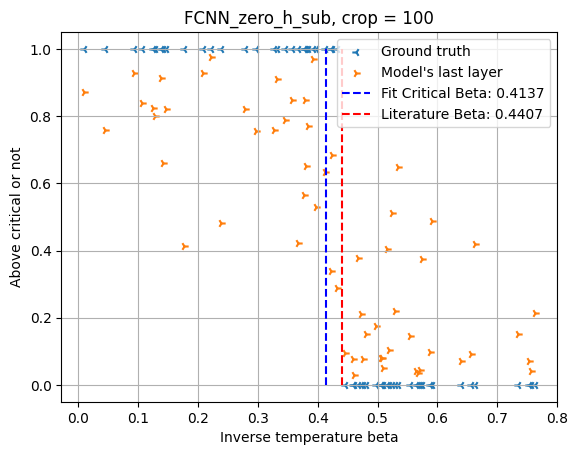

In [10]:
#We take cropxcrop randomly positioned submatrices of the samples
CROPS = np.array([190, 160, 130, 100])

for crop in CROPS:
    FCNN_zero_h_sub = models.Sequential([
    layers.Input(shape=(crop**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
    ])

    FCNN_zero_h_sub.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
    )
    FCNN_zero_h_sub_weights, predictions = hyper_parameter_search(FCNN_zero_h_sub, list_train, list_eval, list_test, phases_train, phases_test, CROP=crop,
                                                            BS_exponent_interval=[1, 10], E_interval=[1, 20], iter=10, 
                                                            title=f"FCNN_zero_h_sub hyperparameter space, crop = {crop}", flatten = 1)
    FCNN_zero_h_sub.set_weights(FCNN_zero_h_sub_weights)
    fit_critical(betas_test, phases_test, predictions, f"FCNN_zero_h_sub, crop = {crop}")

Training on submatrices decreases model accuracy significantly, though the models did converge. Interestingly the error wasn't found to be a function of the portion of the data that is discarded, right as matrices cease to be static with respect to the neurons we observe the decline.

Case of External Magnetic Field
---
This dataset is plentiful, but contains many values of h.

In [11]:
(list_train, betas_train, hs_train, phases_train,
 list_eval, betas_eval, hs_eval, phases_eval,
 list_test, betas_test, hs_test, phases_test) = load_directory("../2dIsingData/non_zero_h/*.npz")

50/50 [==============================] - 0s 3ms/step


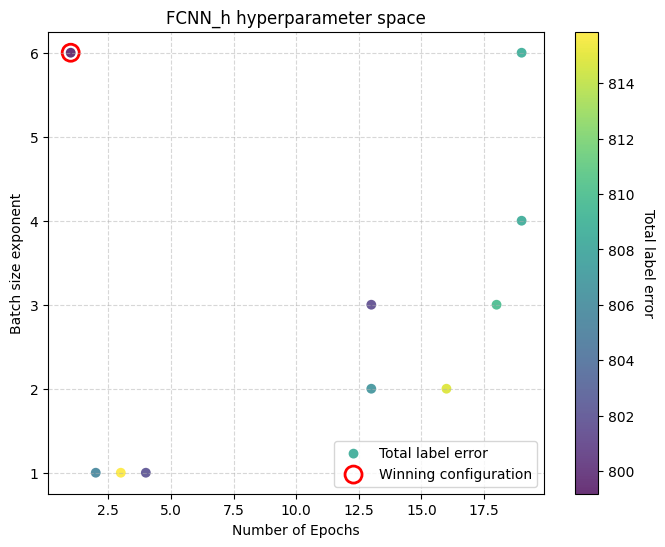

In [12]:
#Use the full sample from now on
CROP=200
FCNN_h = models.Sequential([
    layers.Input(shape=(N**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_h.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

FCNN_h_weights, predictions = hyper_parameter_search(FCNN_h, list_train, list_eval, list_test, phases_train, phases_test, CROP=CROP,
                                                         BS_exponent_interval=[1, 7], E_interval=[1, 20], iter=10, 
                                                         title="FCNN_h hyperparameter space", flatten = 1)
FCNN_h.set_weights(FCNN_h_weights)

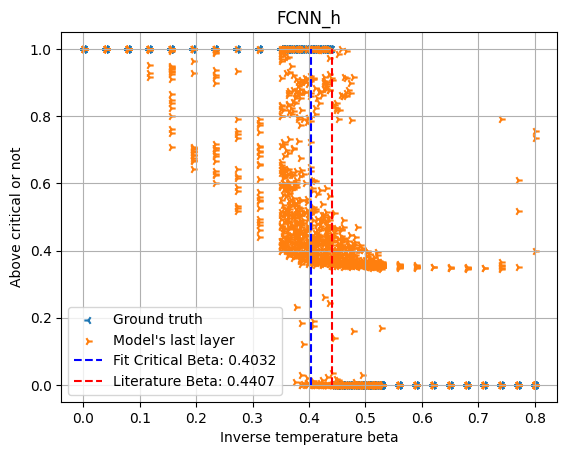

In [13]:
fit_critical(betas_test, phases_test, predictions, "FCNN_h")

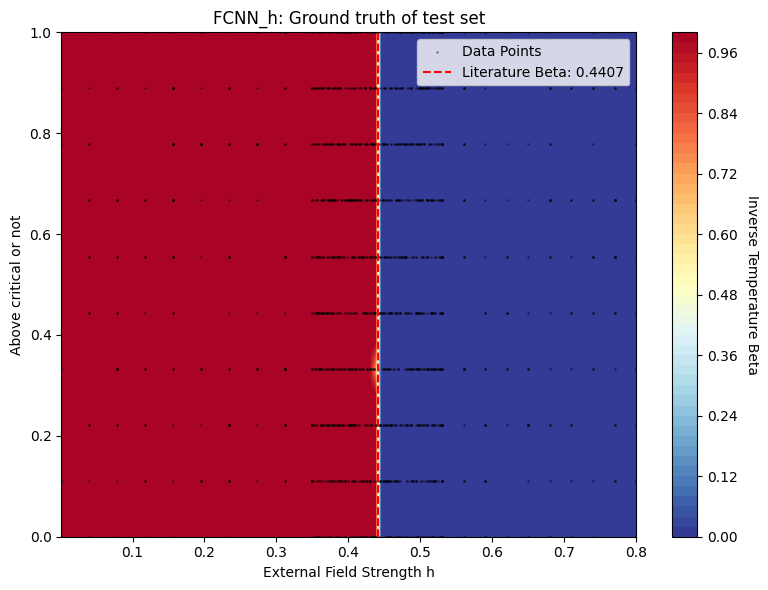

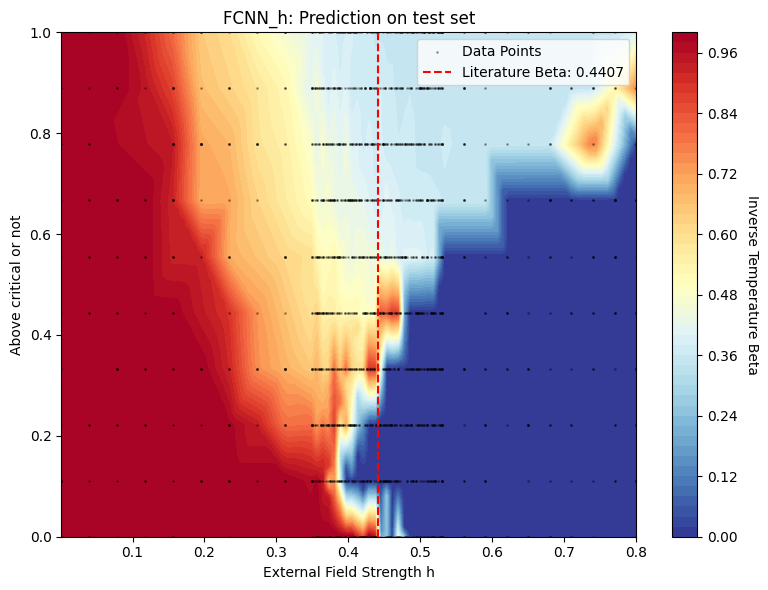

In [14]:
#Interpolates and plots a variable in function of the two passed
def plot_3D(x, y, predictions, plot_title, colorbar_title, xlabel, ylabel, vmin, vmax):
    predictions = predictions.ravel()
    #Create a dense regular 2D grid
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)

    #Interpolate the data
    Z = griddata((x, y), predictions, (X, Y), method='linear')

    #Plot using contourf
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=50, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label(colorbar_title, rotation=270, labelpad=15)

    ax.scatter(x, y, c='black', s=1, alpha=0.3, label='Data Points')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(plot_title)
    fig.tight_layout()

def plot_h_beta(betas, hs, predictions, plot_title,):
    plot_3D(betas, hs, predictions, plot_title, "Inverse Temperature Beta", "External Field Strength h", "Above critical or not", 0, 1)
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')
    plt.legend()
    plt.show()

plot_h_beta(betas_test, hs_test, phases_test, "FCNN_h: Ground truth of test set")
plot_h_beta(betas_test, hs_test, predictions, "FCNN_h: Prediction on test set")

Note: Though "duplicate" datapoints technically are not accounted for during plotting, but they don't make a difference in practice.

We operated under the assumption that phase change would happen at T_c regardless of h (see first plot), this might not be true.

The figure suggests that the external magnetization acts as a source of artificial order in the system, simulating low temperature domains, and shifting the appearant Beta_c ever-lower. This is of course a mistake on the models part.

Relatively Tiny Convolutional Network
---
As the usable structures are inherently 2D, the FCNN investigation was more a curiosity than anything else. The CNN should have a much easier time interpreting its inputs, hopefully distinguishing between magnetization due to external fields and natural domains.

In [15]:
CNN = models.Sequential([
    layers.Input(shape=(N, N, 1)),

    # Using LeakyReLU prevents zeroing out valid negative spin structural features
    layers.Conv2D(16, (5, 5), padding='valid'),
    layers.LeakyReLU(alpha=0.1),
    # Respects sign and acts like local coarse-graining 
    layers.AveragePooling2D((2, 2)), 
    
    layers.Conv2D(32, (5, 5), padding='valid'),
    layers.LeakyReLU(alpha=0.1),
    layers.AveragePooling2D((2, 2)),
    
    #Avarage together the 32 layers
    layers.GlobalAveragePooling2D(),
    # Standard ReLU is fine in the global neck
    layers.Dense(36, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

CNN.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

50/50 [==============================] - 0s 7ms/step


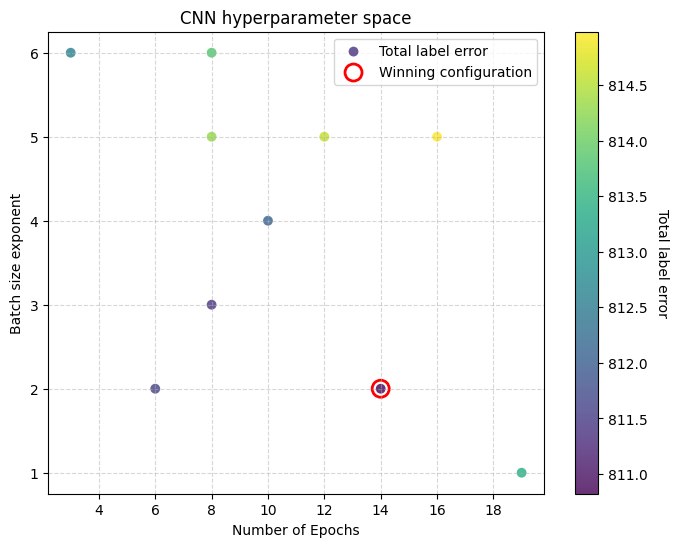

In [16]:
CNN_weights, predictions_test = hyper_parameter_search(CNN, list_train, list_eval, list_test, phases_train, phases_test, CROP=CROP,
                                                         BS_exponent_interval=[1, 7], E_interval=[1, 20], iter=10, 
                                                         title="CNN hyperparameter space", flatten = 0)
CNN.set_weights(CNN_weights)

In [17]:
train_matrices = np.array([matrix_from_file(file_path) for file_path in list_train])
predictions_train = CNN.predict(train_matrices[..., np.newaxis])

150/150 [==============================] - 1s 7ms/step


Let's see predictions on the training set first for a change


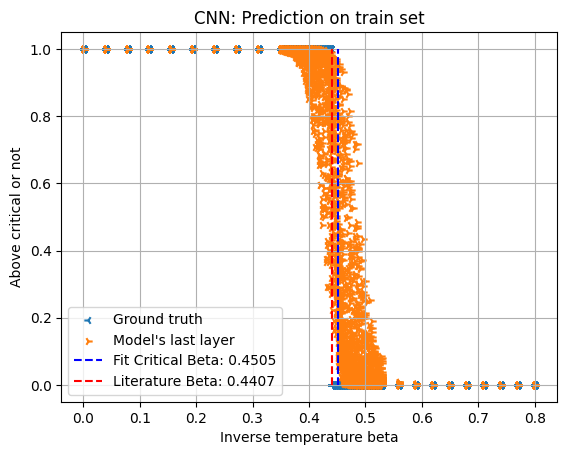

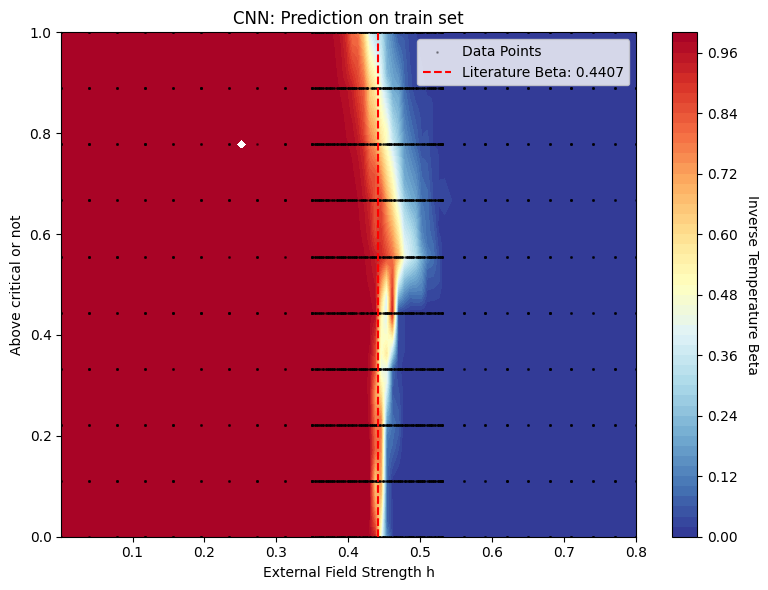

Predictions on test set


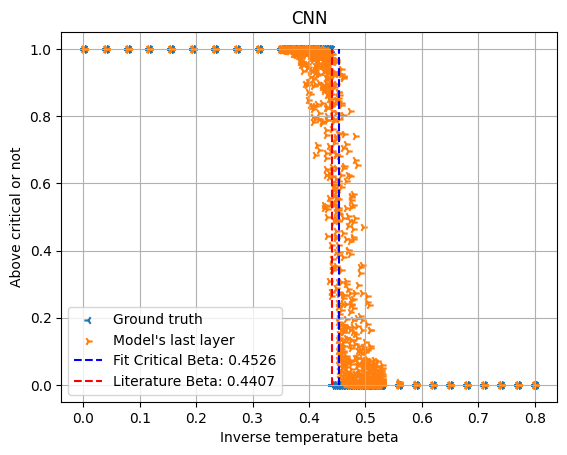

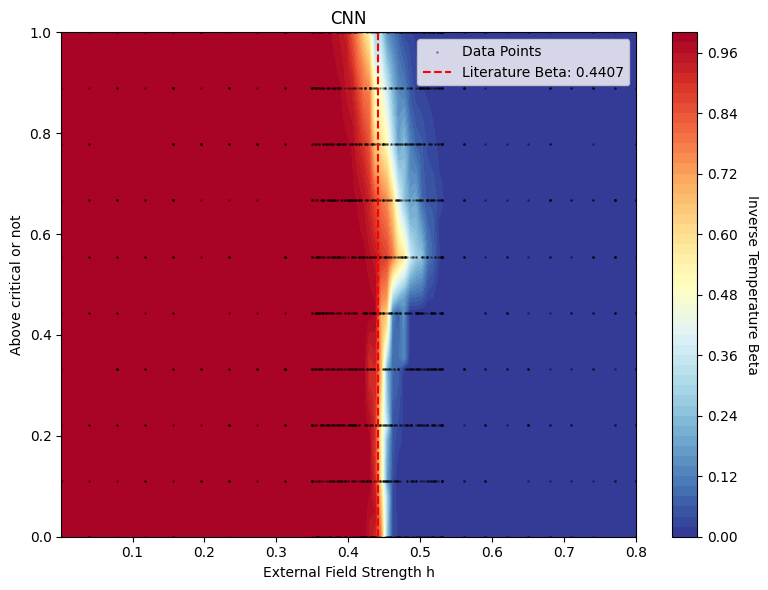

In [18]:
print("Let's see predictions on the training set first for a change")
fit_critical(betas_train, phases_train, predictions_train, "CNN: Prediction on train set")
plot_h_beta(betas_train, hs_train, predictions_train, "CNN: Prediction on train set")

print("Predictions on test set")
fit_critical(betas_test, phases_test, predictions_test, "CNN")
plot_h_beta(betas_test, hs_test, predictions_test, "CNN")

The model is generally correct about the systems phase, regardless of external field strength, though there are some deviations.